# Analyse exploratoire du marché de l'emploi tech en France

## Objectif

Cette étape décrit la structure du jeu de données et analyse :

- la répartition des offres par zone géographique ;
- la répartition des familles de métiers tech ;
- les types de contrat ;
- les familles de métiers ;
- la disponibilité et la distribution des salaires ;
- les principales valeurs manquantes.

Le fichier produit à la fin de l'analyse sera utilisé pour l'extraction des compétences.

## 1. Imports

In [3]:
from pathlib import Path
import re
import unicodedata

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

## 2. Chargement des données

In [6]:
DATA_PATH = Path("offres_emploi_tech_clean.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("offres_emploi_tech.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Aucun fichier de données n'a été trouvé dans le dossier courant."
    )

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print(f"Fichier chargé : {DATA_PATH}")
print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

df.head()

Fichier chargé : offres_emploi_tech_clean.csv
Dimensions : 991 lignes × 18 colonnes


,id,titre,description,type_contrat,experience,ville,secteur,entreprise,salaire_min,salaire_max,salaire_moy,date_publication,mot_cle_source,salaire_moy_avant_correction,salaire_corrige_heuristique,departement,ville_clean,contrat_simplifie
0,210LQML,Chef de projet informatique DATA (H/F),Rattaché(e) au Directeur du service informatiq...,CDI,1 An(s) - Sur poste similaire,55 - BRAS-SUR-MEUSE,Commerce de gros (commerce interentreprises) d...,EMC2,NaN,NaN,NaN,2026-06-29 14:04:21.520000+00:00,machine learning,NaN,False,55.0,BRAS-SUR-MEUSE,CDI
1,210LNTS,Data manager (F/H),En intégrant une communauté d'experts passionn...,CDI,3 An(s),31 - Toulouse,Activités des agences de travail temporaire,RANDSTAD PROFESSIONAL,40000.0,0.0,40000.0,2026-06-29 13:03:07.107000+00:00,data engineer,20000.0,True,31.0,Toulouse,CDI
2,210LGWN,Data engineer (BI) - H/F/X (H/F),Nous recherchons un(e) Data Engineer passionné...,CDI,4 An(s),93 - ST DENIS,Vente à distance sur catalogue général,VENTE PRIVEE.COM,NaN,NaN,NaN,2026-06-29 11:01:04.587000+00:00,data engineer,NaN,False,93.0,ST DENIS,CDI
3,210LDDF,Consultant BI / Décisionnel (H/F),Vous souhaitez rejoindre un environnement où l...,CDI,4 An(s),84 - Avignon,Conseil pour les affaires et autres conseils d...,GROUPAGORA,40000.0,0.0,40000.0,2026-06-29 10:18:03.314000+00:00,business intelligence,20000.0,True,84.0,Avignon,CDI
4,210LCDC,Chargé de projet data analyst (H/F),Chargé(e) de Projets / Data Analyst (CDD) - Pa...,CDD - 6 Mois,2 An(s),75 - PARIS,Commerce de gros (commerce interentreprises) d...,REXEL FRANCE,35000.0,0.0,35000.0,2026-06-29 09:58:36.173000+00:00,data analyst,17500.0,True,75.0,Paris,CDD


## 3. Vérification des colonnes

In [9]:
REQUIRED_COLUMNS = {
    "id",
    "titre",
    "description",
    "type_contrat",
    "ville",
    "date_publication",
    "salaire_moy",
}

missing_columns = REQUIRED_COLUMNS.difference(df.columns)

if missing_columns:
    missing_list = ", ".join(sorted(missing_columns))
    raise ValueError(f"Colonnes manquantes : {missing_list}")

print("Toutes les colonnes nécessaires sont présentes.")

Toutes les colonnes nécessaires sont présentes.


## 4. Préparation des variables

In [12]:
INVALID_LOCATIONS = {
    "france",
    "non renseignee",
}

OUT_OF_SCOPE_LOCATIONS = {
    "suisse",
    "luxembourg",
}

ILE_DE_FRANCE_LABELS = {
    "ile-de-france",
    "hauts-de-seine",
}

ILE_DE_FRANCE_DEPARTMENTS = {
    "75", "77", "78", "91", "92", "93", "94", "95"
}

ILE_DE_FRANCE_CITIES = {
    "paris",
    "nanterre",
    "courbevoie",
    "puteaux",
    "levallois-perret",
    "boulogne-billancourt",
    "issy-les-moulineaux",
    "neuilly-sur-seine",
    "saint-denis",
    "montreuil",
    "versailles",
    "massy",
    "creteil",
    "vincennes",
    "velizy-villacoublay",
    "cergy",
    "rungis",
    "roissy-en-france",
}

METROPOLITAN_AREAS = {
    "Toulouse Métropole": {
        "toulouse",
        "blagnac",
        "colomiers",
        "balma",
        "labege",
        "ramonville-saint-agne",
        "tournefeuille",
        "saint-orens-de-gameville",
        "l'union",
    },
    "Lyon Métropole": {
        "lyon",
        "villeurbanne",
        "bron",
        "venissieux",
        "caluire-et-cuire",
        "saint-priest",
        "ecully",
    },
    "Bordeaux Métropole": {
        "bordeaux",
        "merignac",
        "pessac",
        "talence",
        "begles",
        "cenon",
        "bruges",
    },
    "Nantes Métropole": {
        "nantes",
        "saint-herblain",
        "reze",
        "carquefou",
        "vertou",
        "orvault",
    },
    "Lille Métropole": {
        "lille",
        "roubaix",
        "tourcoing",
        "villeneuve-d'ascq",
        "marcq-en-baroeul",
        "wasquehal",
    },
    "Rennes Métropole": {
        "rennes",
        "bruz",
        "cesson-sevigne",
        "saint-gregoire",
        "chantepie",
    },
    "Montpellier Méditerranée Métropole": {
        "montpellier",
        "lattes",
        "castelnau-le-lez",
        "mauguio",
        "perols",
    },
    "Grenoble-Alpes Métropole": {
        "grenoble",
        "meylan",
        "echirolles",
        "saint-martin-d'heres",
        "fontaine",
    },
    "Aix-Marseille-Provence": {
        "marseille",
        "aix-en-provence",
        "vitrolles",
        "aubagne",
        "marignane",
    },
}


def normalize_text(value):
    if pd.isna(value):
        return ""

    text = str(value).lower().strip()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(
        character
        for character in text
        if not unicodedata.combining(character)
    )

    return text


def clean_city(value):
    if pd.isna(value):
        return pd.NA

    city = str(value).strip()

    if " - " in city:
        city = city.split(" - ", 1)[1].strip()

    city = re.sub(
        r"\s+CEDEX(?:\s+\d+)?$",
        "",
        city,
        flags=re.IGNORECASE,
    ).strip()

    city_normalized = normalize_text(city)

    if city_normalized in INVALID_LOCATIONS:
        return pd.NA

    if city_normalized.startswith("paris"):
        return "Paris"

    if city_normalized.startswith("lyon"):
        return "Lyon"

    if city_normalized.startswith("marseille"):
        return "Marseille"

    return city


def extract_department(value):
    if pd.isna(value):
        return pd.NA

    match = re.match(r"^\s*(\d{2,3})\s*-", str(value))

    if match:
        return match.group(1)

    return pd.NA


def assign_geographic_area(row):
    department = row["departement"]
    city = normalize_text(row["ville_clean"])
    original_location = normalize_text(row["ville"])

    if original_location in ILE_DE_FRANCE_LABELS:
        return "Île-de-France"

    if department in ILE_DE_FRANCE_DEPARTMENTS:
        return "Île-de-France"

    if city in ILE_DE_FRANCE_CITIES:
        return "Île-de-France"

    for area_name, cities in METROPOLITAN_AREAS.items():
        if city in cities:
            return area_name

    if not city:
        return pd.NA

    return row["ville_clean"]


def simplify_contract(value):
    contract = normalize_text(value)

    if "cdi" in contract:
        return "CDI"

    if "cdd" in contract:
        return "CDD"

    if "interim" in contract:
        return "Intérim"

    if "alternance" in contract or "apprentissage" in contract:
        return "Alternance"

    if not contract:
        return "Non renseigné"

    return "Autre"


CATEGORY_PATTERNS = {
    "MLOps": [
        r"\bmlops\b",
        r"\bmachine learning operations\b",
    ],
    "Ingénieur IA / ML": [
        r"\b(?:ingenieur|engineer).*(?:\bia\b|\bai\b|machine learning|deep learning|computer vision)\b",
        r"\b(?:\bia\b|\bai\b|machine learning|deep learning|computer vision).*(?:ingenieur|engineer)\b",
        r"\btech lead.*(?:\bia\b|\bai\b)\b",
    ],
    "IA / Machine Learning": [
        r"\bmachine learning\b",
        r"\bdeep learning\b",
        r"\bcomputer vision\b",
        r"\bintelligence artificielle\b",
        r"\bia generative\b",
        r"\bconsultant.*\bia\b",
        r"\bconsultant.*\bai\b",
        r"\bexpert ia\b",
        r"\brecherche ia\b",
        r"\bapprentissage ia\b",
        r"\bdata/ia\b",
        r"\bdata & ai\b",
        r"\bsemantic.*parole\b",
        r"\banonymisation.*parole\b",
        r"\btraitement d'images\b",
        r"\balgorithme\b",
        r"\bmodelisation.*donnees\b",
        r"\bia embarquee\b",
    ],
    "Data Scientist": [
        r"\bdata scientist\b",
        r"\bdata science\b",
        r"\bdata sciences\b",
        r"\bscientifique des donnees\b",
        r"\bactuaire.*data\b",
        r"\bbioinformatics\b",
        r"\bbio-informatique\b",
    ],
    "Data Architecture": [
        r"\barchitecte data\b",
        r"\bdata architect\b",
        r"\barchitecture data\b",
        r"\bdata space.*solution owner\b",
    ],
    "Data Management / Governance": [
        r"\bdata manager\b",
        r"\bmaster data\b",
        r"\bdata steward\b",
        r"\bdata quality\b",
        r"\bdata governance\b",
        r"\bgouvernance data\b",
        r"\bdata officer\b",
        r"\bresponsable data\b",
        r"\bhead of data\b",
        r"\bchief data\b",
        r"\bdata strategist\b",
    ],
    "Data Project / Product": [
        r"\bchef.*projet.*data\b",
        r"\bchef.*projet.*ia\b",
        r"\blead projet data\b",
        r"\bdata product\b",
        r"\bproduct owner\b",
        r"\bsolution owner\b",
        r"\bmanager data\b",
        r"\bdigitalisation.*ia\b",
    ],
    "Data Engineer": [
        r"\bdata engineer\b",
        r"\bdata ingenieur\b",
        r"\bingenieur data\b",
        r"\btechnicien data\b",
        r"\banalytics engineer\b",
        r"\bdata platform\b",
        r"\bdata fabric\b",
        r"\bbig data\b",
        r"\bdatabricks\b",
        r"\btalend\b",
        r"\bclickhouse\b",
        r"\bmes historian\b",
        r"\bmethodes data\b",
        r"\badtech engineer\b",
    ],
    "Data Analyst / BI": [
        r"\bdata analyst\b",
        r"\banalyste data\b",
        r"\bdata analytics\b",
        r"\bdigital & analytics\b",
        r"\bbusiness intelligence\b",
        r"\bbi analyst\b",
        r"\bconsultant bi\b",
        r"\bdeveloppeur bi\b",
        r"\breporting analyst\b",
        r"\bmicrostrategy\b",
        r"\banalyste quantitatif\b",
        r"\banalyste des previsions\b",
        r"\bstatisticien\b",
        r"\bstatistiques\b",
    ],
    "Data Consulting / Business Analysis": [
        r"\bconsultant.*data\b",
        r"\bconsultante.*data\b",
        r"\bbusiness analyst\b",
        r"\bbusiness consultant\b",
        r"\bstrategy.*data\b",
        r"\bstrategie.*data\b",
    ],
    "Cloud / DevOps / Systems": [
        r"\bdevops\b",
        r"\bplatform engineer\b",
        r"\bsystems engineer\b",
        r"\bcloud\b",
        r"\bserveur\b",
        r"\binfrastructure\b",
        r"\bsauvegarde\b",
        r"\brestauration\b",
        r"\banalyste d'exploitation\b",
        r"\bsupport applicatif\b",
        r"\bsocle logiciel\b",
    ],
    "Cybersecurity": [
        r"\bcybersecurite\b",
        r"\bcybersecurity\b",
        r"\bsecurite applicative\b",
        r"\bappsec\b",
        r"\bsecurity specialist\b",
        r"\bnetwork & security\b",
    ],
    "Software Engineering": [
        r"\bsoftware engineer\b",
        r"\bingenieur logiciel\b",
        r"\bingenierie logicielle\b",
        r"\banalyste programmeur\b",
        r"\bdeveloppeur\b",
        r"\bdeveloppement python\b",
        r"\bbackend\b",
        r"\bback-end\b",
        r"\bdjango\b",
        r"\btypescript\b",
        r"\bvue\.js\b",
        r"\bjava\b",
        r"\bangular\b",
        r"\bc\+\+\b",
        r"\brobotique\b",
        r"\brecherche informatique\b",
    ],
    "Hardware / Embedded": [
        r"\bhardware\b",
        r"\bverification engineer\b",
        r"\bsignal integrity\b",
        r"\bfpga\b",
        r"\bembarque\b",
        r"\bdata wiring\b",
    ],
    "IT Consulting / Digital": [
        r"\bconsultant informatique\b",
        r"\btransformation digitale\b",
        r"\bcto advisory\b",
        r"\bdigital workplace\b",
        r"\bit operating model\b",
        r"\bagilite\b",
        r"\bmoe ecm\b",
        r"\bged\b",
    ],
    "IT Management": [
        r"\bdirecteur numerique\b",
        r"\bdirecteur informatique\b",
        r"\bcio\b",
        r"\bcto\b",
    ],
}

SOURCE_KEYWORD_CATEGORIES = {
    "data analyst": "Data Analyst / BI",
    "business intelligence": "Data Analyst / BI",
    "data scientist": "Data Scientist",
    "data engineer": "Data Engineer",
    "machine learning": "IA / Machine Learning",
    "intelligence artificielle": "IA / Machine Learning",
    "mlops": "MLOps",
}

OUT_OF_SCOPE_PATTERNS = [
    r"\baide menager\b",
    r"\bemploye.*menage\b",
    r"\bagent d'entretien\b",
    r"\bconducteur de ligne\b",
    r"\bconducteur vl\b",
    r"\btechnicien.*production.*mecanique\b",
    r"\bmaintenance industrielle\b",
    r"\bchef de projet en maintenance\b",
    r"\bexpert batiment\b",
    r"\bsecond oeuvre\b",
    r"\bdata centers\b",
    r"\bintegrateur gtb\b",
    r"\bgtb gtc\b",
    r"\bcommercial sedentaire\b",
    r"\bbusiness developer\b",
    r"\bingenieur industriel\b",
    r"\bingenieur calculateur\b",
    r"\befficacite energetique\b",
    r"\bconformite machines\b",
    r"\bthermographie inductive\b",
    r"\bcontrole non destructif\b",
    r"\btechnicien sav\b",
    r"\bformation mecanique\b",
    r"\bpedagogique\b",
    r"\bdigital learning\b",
    r"\blearning & development\b",
    r"\binsertion professionnelle\b",
    r"\benquetes d'insertion\b",
    r"\bdossiers d'expertise\b",
    r"\bexpertise en assurance\b",
    r"\blegal counsel\b",
    r"\bfinance & procurement\b",
    r"\bfinancial services agile\b",
    r"\bmanager business transformation\b",
    r"\bautomatisme industrie manufacturiere\b",
    r"\bmaintenance cvc\b",
]


def matches_pattern(text, patterns):
    return any(re.search(pattern, text) for pattern in patterns)


def get_source_text(row):
    if "mots_cles_sources" in row.index:
        return normalize_text(row["mots_cles_sources"])

    if "mot_cle_source" in row.index:
        return normalize_text(row["mot_cle_source"])

    return ""


def find_category(text):
    for category, patterns in CATEGORY_PATTERNS.items():
        if matches_pattern(text, patterns):
            return category

    return None


def classify_job(row):
    title = normalize_text(row["titre"])

    if matches_pattern(title, OUT_OF_SCOPE_PATTERNS):
        return pd.Series(
            {
                "categorie_metier": "Hors périmètre",
                "source_classification": "titre",
            }
        )

    category = find_category(title)

    if category:
        return pd.Series(
            {
                "categorie_metier": category,
                "source_classification": "titre",
            }
        )

    source = get_source_text(row)

    for keyword, source_category in SOURCE_KEYWORD_CATEGORIES.items():
        if keyword in source:
            return pd.Series(
                {
                    "categorie_metier": source_category,
                    "source_classification": "mot-clé de collecte",
                }
            )

    description = normalize_text(row["description"])
    category = find_category(description)

    if category:
        return pd.Series(
            {
                "categorie_metier": category,
                "source_classification": "description",
            }
        )

    return pd.Series(
        {
            "categorie_metier": "Non classé",
            "source_classification": "aucune",
        }
    )

df = df.copy()

location_normalized = df["ville"].apply(normalize_text)
out_of_scope_mask = location_normalized.isin(OUT_OF_SCOPE_LOCATIONS)
excluded_offer_count = int(out_of_scope_mask.sum())

df = df.loc[~out_of_scope_mask].copy()

df["date_publication"] = pd.to_datetime(
    df["date_publication"],
    errors="coerce",
    utc=True,
)

df["salaire_moy"] = pd.to_numeric(
    df["salaire_moy"],
    errors="coerce",
)

salary_is_valid = df["salaire_moy"].between(20_000, 150_000)
df.loc[~salary_is_valid, "salaire_moy"] = pd.NA

df["ville_clean"] = df["ville"].apply(clean_city)
df["departement"] = df["ville"].apply(extract_department)
df["zone_geographique"] = df.apply(assign_geographic_area, axis=1)

df["contrat_simplifie"] = df["type_contrat"].apply(simplify_contract)
classification_results = df.apply(classify_job, axis=1)

df[
    [
        "categorie_metier",
        "source_classification",
    ]
] = classification_results

job_out_of_scope_mask = df["categorie_metier"].eq("Hors périmètre")
unclassified_job_mask = df["categorie_metier"].eq("Non classé")

excluded_job_count = int(job_out_of_scope_mask.sum())
unclassified_job_count = int(unclassified_job_mask.sum())

df = df.loc[~job_out_of_scope_mask].copy()
df = df.drop_duplicates(subset="id").reset_index(drop=True)

print(f"Offres exclues pour la localisation : {excluded_offer_count:,}")
print(f"Offres exclues pour le métier : {excluded_job_count:,}")
print(f"Offres non classées : {unclassified_job_count:,}")
print(f"Offres uniques conservées : {len(df):,}")
print(f"Offres avec salaire valide : {df['salaire_moy'].notna().sum():,}")

Offres exclues pour la localisation : 11
Offres exclues pour le métier : 58
Offres non classées : 8
Offres uniques conservées : 922
Offres avec salaire valide : 188


## 5. Vue d'ensemble

In [15]:
overview = pd.DataFrame(
    {
        "Indicateur": [
            "Nombre d'offres",
            "Nombre de zones géographiques",
            "Nombre de catégories de métiers",
            "Offres avec salaire",
            "Part des offres avec salaire",
            "Salaire médian",
        ],
        "Valeur": [
            f"{len(df):,}",
            f"{df['zone_geographique'].nunique(dropna=True):,}",
            f"{df['categorie_metier'].nunique():,}",
            f"{df['salaire_moy'].notna().sum():,}",
            f"{df['salaire_moy'].notna().mean() * 100:.1f} %",
            (
                f"{df['salaire_moy'].median():,.0f} €"
                if df["salaire_moy"].notna().any()
                else "Non disponible"
            ),
        ],
    }
)

overview

,Indicateur,Valeur
0,Nombre d'offres,922
1,Nombre de zones géographiques,159
2,Nombre de catégories de métiers,17
3,Offres avec salaire,188
4,Part des offres avec salaire,20.4 %
5,Salaire médian,"45,000 €"


## 6. Valeurs manquantes

In [18]:
missing_values = pd.DataFrame(
    {
        "nombre_manquant": df.isna().sum(),
        "pourcentage_manquant": df.isna().mean() * 100,
    }
)

missing_values = missing_values.sort_values(
    "pourcentage_manquant",
    ascending=False,
)

missing_values["pourcentage_manquant"] = (
    missing_values["pourcentage_manquant"].round(1)
)

missing_values

,nombre_manquant,pourcentage_manquant
salaire_moy,734,79.6
date_publication,731,79.3
salaire_moy_avant_correction,683,74.1
salaire_min,683,74.1
salaire_max,683,74.1
entreprise,488,52.9
secteur,465,50.4
departement,22,2.4
zone_geographique,18,2.0
ville_clean,18,2.0


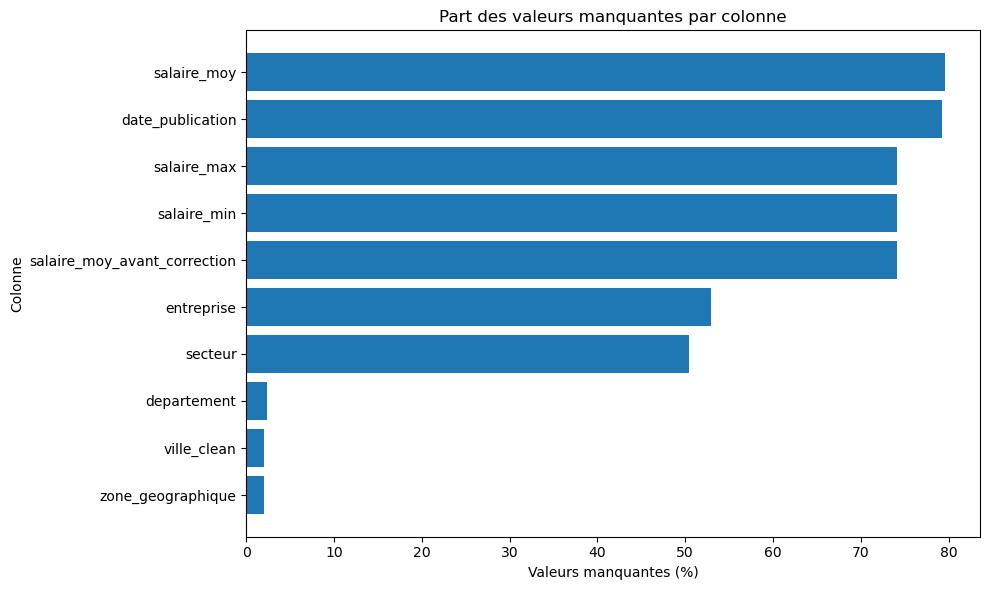

In [20]:
missing_to_plot = missing_values[
    missing_values["pourcentage_manquant"] > 0
].sort_values("pourcentage_manquant")

plt.figure(figsize=(10, 6))
plt.barh(
    missing_to_plot.index,
    missing_to_plot["pourcentage_manquant"],
)
plt.title("Part des valeurs manquantes par colonne")
plt.xlabel("Valeurs manquantes (%)")
plt.ylabel("Colonne")
plt.tight_layout()
plt.show()

## 7. Répartition par zone géographique

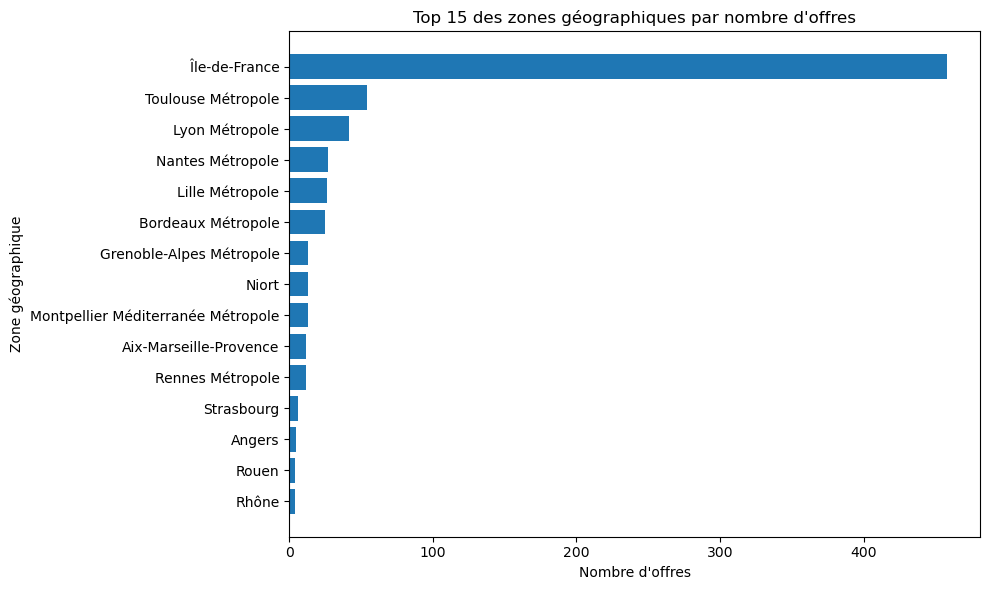

,nombre_offres
zone_geographique,
Île-de-France,458
Toulouse Métropole,54
Lyon Métropole,42
Nantes Métropole,27
Lille Métropole,26
Bordeaux Métropole,25
Montpellier Méditerranée Métropole,13
Niort,13
Grenoble-Alpes Métropole,13


In [23]:
top_areas = (
    df["zone_geographique"]
    .dropna()
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(top_areas.index, top_areas.values)
plt.title("Top 15 des zones géographiques par nombre d'offres")
plt.xlabel("Nombre d'offres")
plt.ylabel("Zone géographique")
plt.tight_layout()
plt.show()

top_areas.sort_values(
    ascending=False
).to_frame("nombre_offres")

## 8. Répartition des contrats

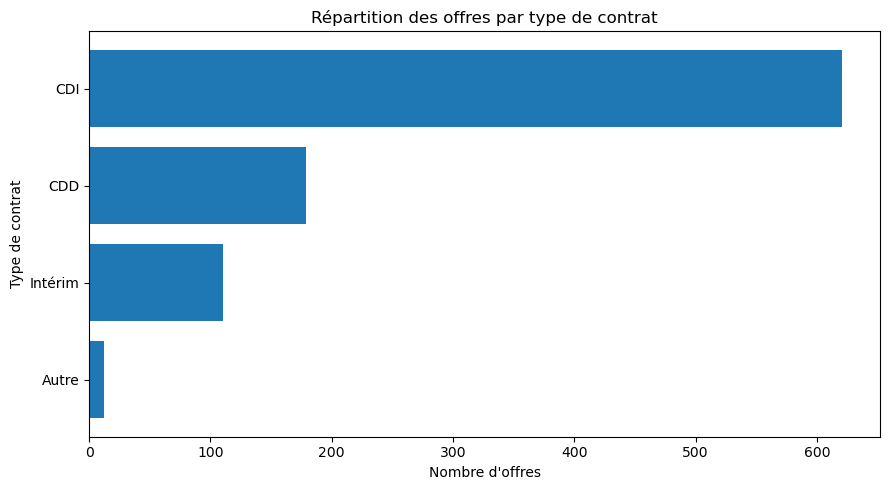

,nombre_offres
contrat_simplifie,
CDI,621
CDD,179
Intérim,110
Autre,12


In [26]:
contract_counts = df["contrat_simplifie"].value_counts().sort_values()

plt.figure(figsize=(9, 5))
plt.barh(contract_counts.index, contract_counts.values)
plt.title("Répartition des offres par type de contrat")
plt.xlabel("Nombre d'offres")
plt.ylabel("Type de contrat")
plt.tight_layout()
plt.show()

contract_counts.sort_values(ascending=False).to_frame("nombre_offres")

## 9. Répartition des métiers

Les intitulés sont classés avec des règles ordonnées fondées sur des expressions régulières. Les catégories les plus spécifiques, comme l'architecture ou la gouvernance des données, sont évaluées avant les catégories plus générales.

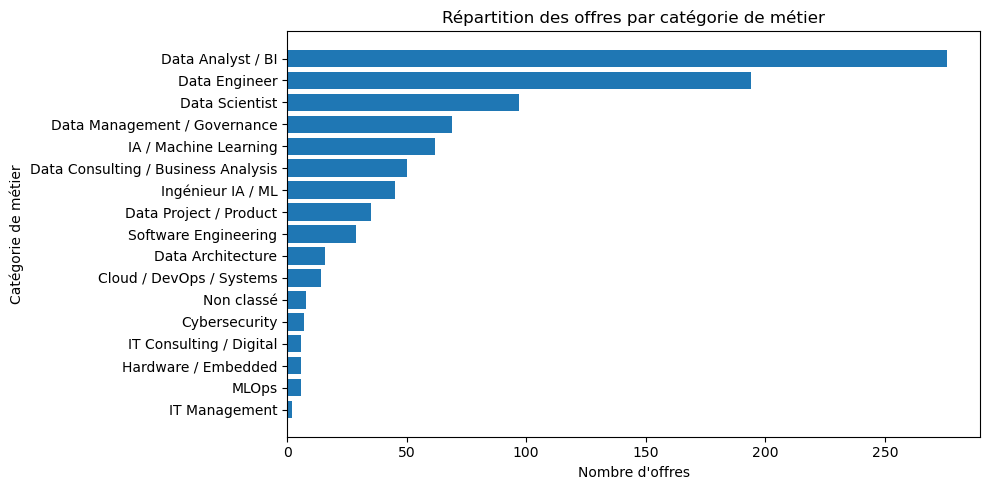

,nombre_offres
categorie_metier,
Data Analyst / BI,276
Data Engineer,194
Data Scientist,97
Data Management / Governance,69
IA / Machine Learning,62
Data Consulting / Business Analysis,50
Ingénieur IA / ML,45
Data Project / Product,35
Software Engineering,29


In [29]:
job_counts = df["categorie_metier"].value_counts().sort_values()

plt.figure(figsize=(10, 5))
plt.barh(job_counts.index, job_counts.values)
plt.title("Répartition des offres par catégorie de métier")
plt.xlabel("Nombre d'offres")
plt.ylabel("Catégorie de métier")
plt.tight_layout()
plt.show()

job_counts.sort_values(ascending=False).to_frame("nombre_offres")

## 10. Distribution des salaires

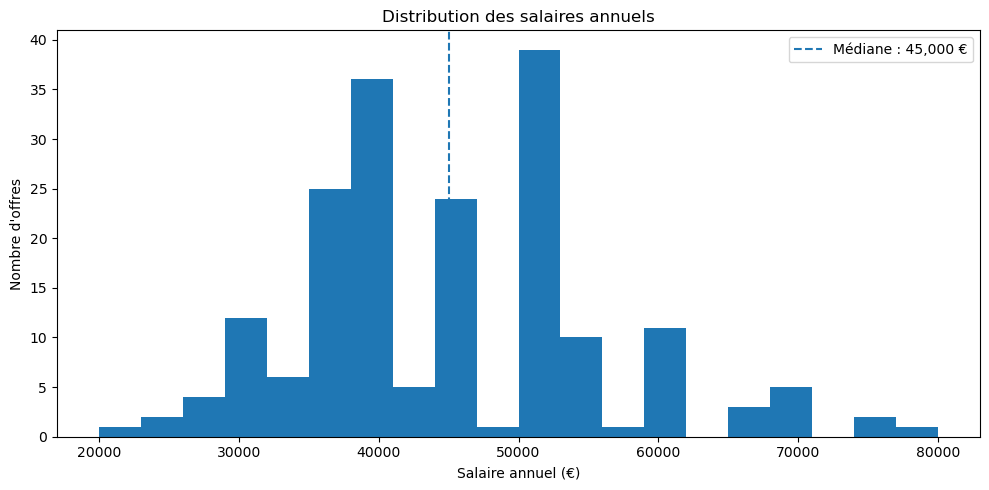

,salaire_annuel
count,188.0
mean,44625.0
std,10691.0
min,20000.0
25%,37000.0
50%,45000.0
75%,50000.0
max,80000.0


In [32]:
salary_data = df["salaire_moy"].dropna()

if salary_data.empty:
    print("Aucun salaire valide n'est disponible.")
else:
    plt.figure(figsize=(10, 5))
    plt.hist(salary_data, bins=20)
    plt.axvline(
        salary_data.median(),
        linestyle="--",
        label=f"Médiane : {salary_data.median():,.0f} €",
    )
    plt.title("Distribution des salaires annuels")
    plt.xlabel("Salaire annuel (€)")
    plt.ylabel("Nombre d'offres")
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(salary_data.describe().round(0).to_frame("salaire_annuel"))

## 11. Salaire médian par métier

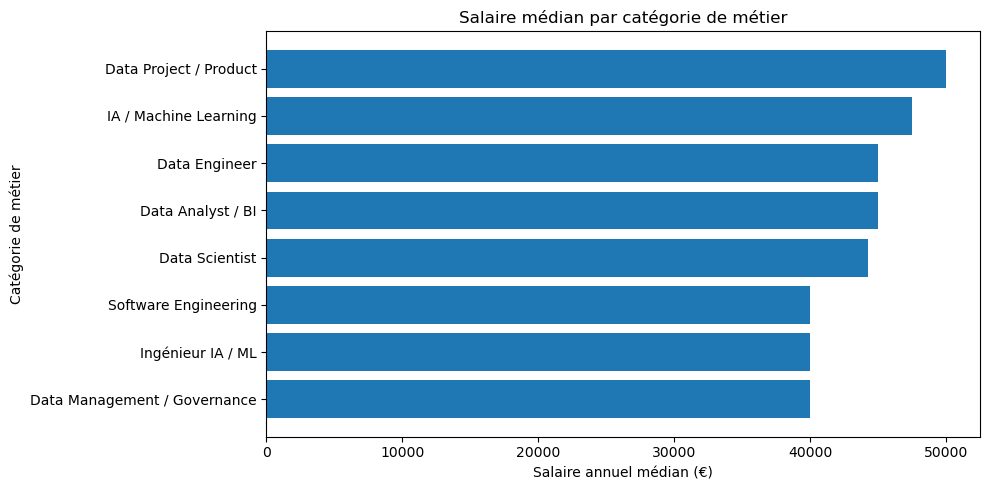

,categorie_metier,nombre_offres,salaire_median
0,Data Project / Product,7,50000.0
1,IA / Machine Learning,6,47500.0
2,Data Analyst / BI,55,45000.0
3,Data Engineer,44,45000.0
4,Data Scientist,16,44250.0
5,Data Management / Governance,25,40000.0
6,Ingénieur IA / ML,11,40000.0
7,Software Engineering,7,40000.0


In [35]:
salary_by_job = (
    df.dropna(subset=["salaire_moy"])
    .groupby("categorie_metier")["salaire_moy"]
    .agg(nombre_offres="count", salaire_median="median")
    .reset_index()
)

salary_by_job = salary_by_job[
    salary_by_job["nombre_offres"] >= 5
].sort_values("salaire_median")

if salary_by_job.empty:
    print("Pas assez d'offres avec salaire pour comparer les métiers.")
else:
    plt.figure(figsize=(10, 5))
    plt.barh(
        salary_by_job["categorie_metier"],
        salary_by_job["salaire_median"],
    )
    plt.title("Salaire médian par catégorie de métier")
    plt.xlabel("Salaire annuel médian (€)")
    plt.ylabel("Catégorie de métier")
    plt.tight_layout()
    plt.show()

    display(
        salary_by_job.sort_values(
            "salaire_median",
            ascending=False,
        ).reset_index(drop=True)
    )

## 12. Synthèse automatique

In [38]:
main_area = df["zone_geographique"].dropna().value_counts().idxmax()
main_contract = df["contrat_simplifie"].value_counts().idxmax()
main_job = df["categorie_metier"].value_counts().idxmax()

if df["salaire_moy"].notna().any():
    median_salary = f"{df['salaire_moy'].median():,.0f} €"
else:
    median_salary = "non disponible"

summary = f"""
### Principaux résultats

- **Zone géographique la plus représentée :** {main_area}
- **Type de contrat dominant :** {main_contract}
- **Catégorie de métier dominante :** {main_job}
- **Salaire annuel médian :** {median_salary}
- **Part des offres avec salaire :** {df['salaire_moy'].notna().mean() * 100:.1f} %
"""

display(Markdown(summary))


### Principaux résultats

- **Zone géographique la plus représentée :** Île-de-France
- **Type de contrat dominant :** CDI
- **Catégorie de métier dominante :** Data Analyst / BI
- **Salaire annuel médian :** 45,000 €
- **Part des offres avec salaire :** 20.4 %


## 13. Export des données enrichies

In [41]:
OUTPUT_PATH = Path("offres_emploi_tech_eda.csv")

df.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print(f"Fichier sauvegardé : {OUTPUT_PATH}")

Fichier sauvegardé : offres_emploi_tech_eda.csv


## Conclusion

L'analyse exploratoire permet de vérifier la qualité du jeu de données et d'identifier les principales tendances du marché. Les offres hors de France et les intitulés clairement hors du périmètre tech ont été exclus.

Le fichier enrichi contient des variables homogènes pour la localisation, le contrat et la famille de métier. La prochaine étape consiste à extraire automatiquement les compétences mentionnées dans les descriptions des offres.